# TD 2 : Manipulation de données

Christelle Gonindard, Matthias Grenié, et François Bettega

<div class="alert alert-info">

## Objectifs

- Extraire une valeur d'un tableau
- Filtrer des lignes d'un tableau
- Sélectionner des colonnes
- Connaître l'utilisation des crochets `[]` pour extraire des informations d'un tableau ou l'alternative avec `subset()`
- Mesurer la taille d'un tableau avec `nrow()`, `ncol()`, et `dim()`

</div>

## 1. Rappel sur les données

Le jeu de données contient les variables suivantes en colonne :
- `hamilton_g1` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 1 ;
- `hamilton_g2` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 2 ;
- `age_g1` : l’âge des patients du groupe 1 ;
- `age_g2` : l’âge des patients du groupe 2 ;
- `poids_g1` : le poids des patients du groupe 1 ;
- `poids_g2` : le poids des patients du groupe 2 ;
- `sexe_g1` : le sexe des patients du groupe 1 (`"F"` : femme, `"H"` : homme) ;
- `sexe_g2` : le sexe des patients du groupe 2 (`"F"` : femme, `"H"` : homme) ;
- `urbanisation_g1` : le niveau d’urbanisation dans lequel vivent les patients du groupe 1 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé) ;
- `urbanisation_g2` : le niveau d’urbanisation dans lequel vivent les patients du groupe 2 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé).

## 2. Recharger les données

Quand on ouvre un nouveau notebook, les objets créés et chargés dans les autres notebooks ne sont pas disponibles, il faut donc les charger à nouveau.

Pour mémoire les données sont contenues dans le fichier texte nommé `depression.txt` qui se trouve dans le dossier `data`. Le chemin d'accès complet du fichier est donc `data/depression.txt`. Il faut utiliser la fonction `read.table()` en précisant aussi l'argument `header = TRUE`

In [1]:
# Chargez les données
depression = read.table("data/depression.txt", header = TRUE)

Afficher les premières lignes du tableau avec la fonction `head()`

In [2]:
head(depression)

,hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,43,25,B,B,57,48,74,93,F,H
2,29,29,A,B,37,41,95,92,H,H
3,34,18,A,A,7,30,84,86,H,H
4,39,23,A,A,37,41,104,81,H,H
5,40,24,B,A,15,30,92,74,H,F
6,41,25,B,B,45,45,85,98,H,H


## 3. Extraction directe de données

Il est possible avec **R** d’extraire des valeurs particulières d’un tableau (*data.frame*). Pour cela, il faut être conscient qu’un tableau est composé de lignes et de colonnes, chaque
valeur du tableau a donc un numéro de ligne *i* et un numéro de colonne *j*. 

Pour extraire une valeur particulière du tableau, il suffit de préciser à **R** son numéro de ligne et de colonne. Par
exemple, nous allons extraire la valeur à la ligne 2 dans la colonne 3 :

In [3]:
# Extraire la valeur de la ligne 2 en colonne 3
# les [] permettent d'extraire une sous partie du tableau
# ce qui est avant la virgule correspond aux lignes et ce qui est après la virgule correspond aux colonnes
depression[2,3]

[1] "A"

Application : Extraire la valeur du tableau qui se situe à la ligne 15 dans la colonne 4

In [4]:
depression[15,4]

[1] "A"

On peut aussi extraire toute une ligne ou tout une colonne en ne mettant rien à la place de l'indice de ligne ou de colonne respectivement (**Attention il faut tout même garder la virgule dans les crochets**).

Par exemple, on peut extraire toute la deuxième ligne du tableau avec :

In [5]:
depression[2,]

,hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
2,29,29,A,B,37,41,95,92,H,H


De même, on peut extraire la troisième colonne avec une expression similaire

In [6]:
depression[, 3]

[1] "B" "A" "A" "A" "B" "B" "A" "A" "A" "A" "B" "A" "B" "A" "A" "B" "A" "B" "A"
[20] "A" "B" "B" "A" "A" "B" "B" "A" "A" "C" "B" "C" "B" "C" "A" "C" "A" "A" "B"
[39] "B" "B" "B" "B" "A" "A" "B" "B" "A" "A" "B" "C"

Application : Extraire la 5ème ligne du tableau, puis extraire la 5ème colonne

In [7]:
# 5ème ligne
depression[5,] 

# 5ème colonne
depression[, 5]

,hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
5,40,24,B,A,15,30,92,74,H,F


[1] 57 37  7 37 15 45 41 33 55 46 28 39 30 39 50 42 44 22 36 37 35 62 46 45 56
[26] 40 46 45 42 41 37 39 52 45 59 41 15 43 28 72 45 49 47 40 41 23 31 44 42 30

## 4. Extraction en fonction de conditions

### 4.1 Introduction aux conditions

Avant d'aller plus loin dans les extractions de sous tableaux, il est important de bien faire la différence entre `=` et le `==`

Lorsque l’on utilise un signe égal `=` nous créons une variable, par exemple ici nous allons attribuer la
valeur 4 à toto :

In [8]:
# si on tape juste toto, R met un message d'erreur car la variable toto est vide
# le =  permet d'affecter une valeur à une variable
toto = 4
toto

[1] 4

Lorsque nous mettons un **`==`**, nous réalisons un test, c'est à dire qu'on teste l'égalité.

Par exemple on peut tester si toto est égal à 9

In [9]:
toto == 9

[1] FALSE

**R** nous répond faux.

**Remarque** : Pour tester si une valeur est différente il faut utiliser **`!=`**.

On peut par exemple tester si toto est différent de 9

In [10]:
toto != 9

[1] TRUE

**R** nous répond vrai.

### 4.2. Extraire une valeur ou une série de valeurs

Il est également possible d’extraire des sous groupes de données au sein d'une colonne. Par exemple, à partir de
notre tableau de données, nous pouvons extraire parmi la colonne scores de Hamilton du groupe 1, uniquement
le score des hommes. 
Nous appellerons ce nouveau groupe : `hamilton_g1_homme.`

Le principe est le suivant :
- On sélectionne la colonne qui nous intéresse, ici il s’agit de `hamilton_g1`, comme si obtenir toutes les valeurs de la colonne avec `$`
- Comme on veut extraire des valeurs de cette colonne, on a besoin d'utiliser les crochets `[ ]`
- Seul le score des hommes nous intéresse, il est donc nécessaire de préciser à **R** qu'au sein de cette colonne, nous ne garderons que les lignes correspondantes aux hommes (on met l'expression logique dans les crochets)

In [11]:
# Décomposons :
# 1. on extrait la colonne
depression$hamilton_g1
# 2. on veut extraire des valeurs de la colonnes avec '[]'
depression$hamilton_g1[]
# 3. on formule l'expression logique pour nos valeurs
depression$sexe_g1 == "H"
# 4. on assemble tout
depression$hamilton_g1[depression$sexe_g1 == "H"]

# 5. on assigne la variable
hamilton_g1_homme = depression$hamilton_g1[depression$sexe_g1 == "H"]
hamilton_g1_homme

[1] 43 29 34 39 40 41 32 36 35 37 43 36 41 37 33 40 38 43 32 32 44 40 36 37 41
[26] 43 37 31 47 41 45 42 46 35 49 33 34 44 40 42 44 40 29 36 42 44 32 37 42 45

[1] 43 29 34 39 40 41 32 36 35 37 43 36 41 37 33 40 38 43 32 32 44 40 36 37 41
[26] 43 37 31 47 41 45 42 46 35 49 33 34 44 40 42 44 40 29 36 42 44 32 37 42 45

[1] FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[13]  TRUE FALSE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE FALSE
[25] FALSE FALSE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE
[37]  TRUE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE
[49]  TRUE  TRUE

[1] 29 34 39 40 41 32 36 35 37 43 36 41 33 40 43 32 32 44 36 37 31 41 45 42 35
[26] 49 33 34 44 40 44 40 29 36 42 32 37 42 45

[1] 29 34 39 40 41 32 36 35 37 43 36 41 33 40 43 32 32 44 36 37 31 41 45 42 35
[26] 49 33 34 44 40 44 40 29 36 42 32 37 42 45

*Entraînement : Extraire le score de Hamilton des personnes du groupe 2 qui se situe dans une
zone urbanisée A*

In [12]:
hamilton_g2_a = depression$hamilton_g1[depression$urbanisation_g1 == "A"]
hamilton_g2_a

[1] 29 34 39 32 36 35 37 36 37 33 38 32 32 36 37 37 31 35 33 34 29 36 32 37

### 4.3 Extraire un sous-tableau

Dans la section précédente on a vu comment extraire une valeur ou une série de valeur sous la forme d'un vecteur, il est également possible d’extraire un sous-tableau de données. Nous allons par exemple
extraire le tableau de données qui est associé aux données du groupe 1, nous l’appellerons
`data_g1`. 

Le principe est le suivant :
- Repérer les colonnes qui sont associées au groupe 1 : ce sont les colonnes impaires 1, 3, 5, 7 et 9.
- Ensuite nous voulons récupérer toutes les lignes

Pour extraire plus d'une colonne, il faut préciser les numéros de plusieurs colonnes à l'aide de la fonction `c()`, en donnant les nombres séparés par des virgules. Par exemple, pour extraire les deux premières colonnes d'un tableau nommé `tab` on écrirait `tab[, c(2, 3)]`

In [13]:
# les [] permettent d'extraire une sous-partie du tableau
# ce qui est avant la virgule correspond aux lignes et ce qui est après la virgule correspond aux colonnes
# nous ne précisons rien poru les ligens car nous les voulons toutes
# pour les colonnes nous précisons les valeurs souhaitées
data_g1 = depression[,c(1, 3, 5, 7,9)]

# affichons le début du nouveau tableau
head(data_g1)

,hamilton_g1,urbanisation_g1,age_g1,poids_g1,sexe_g1
,<int>,<chr>,<int>,<int>,<chr>
1,43,B,57,74,F
2,29,A,37,95,H
3,34,A,7,84,H
4,39,A,37,104,H
5,40,B,15,92,H
6,41,B,45,85,H


*Application : Extraire un nouveau tableau nommé data_g2, qui contient uniquement les colonnes associées au groupe G2

In [14]:
data_g2 = depression[,c(2,4,6,8,10)]

*Note : On peut aussi extraire des colonnes d'un tableau en utilisant les noms de colonnes entre guillemets `"` au sein de la fonction `c()` séparés par des virgules, vous pourriez par exemple tester l'expression `depression[, c("age_g1", "poids_g1", "sexe_g1")]`*

À partir du tableau `data_g1`, nous allons sélectionner un nouveau
tableau qui ne contient que le résultat des femmes. Le principe est le suivant :
- Nous voulons faire une extraction donc il faut utiliser `[]`,
- Nous ne gardons que les lignes où la valeur `"F"` apparaît dans la colonne `sexe_g1`
- Puis nous gardons l'ensemble des colonnes (donc on ne met rien après la virgule dans `[]`)

In [15]:
# Décomposons
# 1. Faisons l'extraction avec `[]`
data_g1[]

# 2. préparons l'expression logique sélectionnant les femmes
data_g1$sexe_g1 == "F"

# 3. On assemble le tout
data_g1[data_g1$sexe_g1 == "F", ]

# 4. On stocke la variable
data_g1_femme = data_g1[data_g1$sexe_g1 == "F",]

head(data_g1_femme) # affiche les premières lignes d'un tableau de données

hamilton_g1,urbanisation_g1,age_g1,poids_g1,sexe_g1
<int>,<chr>,<int>,<int>,<chr>
43,B,57,74,F
29,A,37,95,H
34,A,7,84,H
39,A,37,104,H
40,B,15,92,H
41,B,45,85,H
32,A,41,79,H
36,A,33,92,H
35,A,55,76,H


[1]  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[13] FALSE  TRUE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE  TRUE FALSE  TRUE
[25]  TRUE  TRUE FALSE FALSE  TRUE FALSE FALSE FALSE  TRUE FALSE FALSE FALSE
[37] FALSE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE  TRUE FALSE FALSE
[49] FALSE FALSE

,hamilton_g1,urbanisation_g1,age_g1,poids_g1,sexe_g1
,<int>,<chr>,<int>,<int>,<chr>
1,43,B,57,74,F
14,37,A,39,72,F
17,38,A,44,71,F
22,40,B,62,72,F
24,37,A,45,73,F
25,41,B,56,67,F
26,43,B,40,65,F
29,47,C,42,70,F
33,46,C,52,74,F


,hamilton_g1,urbanisation_g1,age_g1,poids_g1,sexe_g1
,<int>,<chr>,<int>,<int>,<chr>
1,43,B,57,74,F
14,37,A,39,72,F
17,38,A,44,71,F
22,40,B,62,72,F
24,37,A,45,73,F
25,41,B,56,67,F


Extraire une tableau `data_g2_femme` qui ne contient que les informations concernant les femmes du groupes 2

In [16]:
data_g2_femme = data_g2[data_g2$sexe_g2 == "F",]

### 4.4 Combiner les conditions

Il est possible de combiner plusieurs conditions lorsque l'on extrait des données d'un tableau grâce aux intructions :
- **`&`** ([esperluette](https://fr.wikipedia.org/wiki/Esperluette)) qui signifie "**et**" : par exemple on veut extraire du tableau les données concernant les femmes de plus de 40 ans (ce qui se traduit par "être une femme et avoir plus de 40 ans")
- **`|`** ([barre verticale](https://fr.wikipedia.org/wiki/Barre_verticale) ou *pipe*) qui signifie "**ou**" : par exemple on veut extraire du tableau les données concernant soit les femmes soit les personnes de plus de 40 ans, la différence avec le tableau précédent est qu'il sera possible dans ce tableau d'avoir également des hommes de plus de 40 ans

Les conditions combinées sont alors écrites individuellement et séparées de `&` ou `|`

*Appliquer ces deux conditions au tableau `data_g1`*

In [17]:
# tableau les données du groupe 1 concernant les femmes de plus de 40 ans
tab1 <- data_g1[data_g1$sexe_g1 == "F" & data_g1$age_g1 > 40,]
head(tab1)

# tableau les données du groupe 1 concernant soit les femmes soit les personnes de plus de 40 ans
tab2 <- data_g1[data_g1$sexe_g1 == "F" | data_g1$age_g1 > 40,]
head(tab2)

,hamilton_g1,urbanisation_g1,age_g1,poids_g1,sexe_g1
,<int>,<chr>,<int>,<int>,<chr>
1,43,B,57,74,F
17,38,A,44,71,F
22,40,B,62,72,F
24,37,A,45,73,F
25,41,B,56,67,F
29,47,C,42,70,F


,hamilton_g1,urbanisation_g1,age_g1,poids_g1,sexe_g1
,<int>,<chr>,<int>,<int>,<chr>
1,43,B,57,74,F
6,41,B,45,85,H
7,32,A,41,79,H
9,35,A,55,76,H
10,37,A,46,78,H
14,37,A,39,72,F


*Appliquer ces deux conditions au tableau `data_g2`*

In [18]:
# tableau les données G1 concernant les femmes de plus de 40 ans
tab1_bis <- data_g2[data_g2$sexe_g2 == "F" & data_g2$age_g2 > 40,]
head(tab1_bis)

# tableau les données G1 concernant soit les femmes soit les personnes de plus de 40 ans
tab2_bis <- data_g2[data_g2$sexe_g2 == "F" | data_g2$age_g2 > 40,]
head(tab2_bis)

hamilton_g2,urbanisation_g2,age_g2,poids_g2,sexe_g2
<int>,<chr>,<int>,<int>,<chr>


,hamilton_g2,urbanisation_g2,age_g2,poids_g2,sexe_g2
,<int>,<chr>,<int>,<int>,<chr>
1,25,B,48,93,H
2,29,B,41,92,H
4,23,A,41,81,H
5,24,A,30,74,F
6,25,B,45,98,H
7,27,B,41,75,H


*Application :*
- Construire un tableau nommé tab1 qui sélectionne les femmes et la classe Urbanisation "A" 
- Construire un tableau nommé tab2 qui sélectionne les femmes ou la classe Urbanisation "A" 

In [19]:
tab1 <- data_g1[data_g1$sexe_g1=="F" & data_g1$urbanisation_g1 == "A",]
tab2 <- data_g2[data_g2$sexe_g2=="F" | data_g2$urbanisation_g2 == "A",]

### 4.5 Fonction `subset()` : syntaxe alternative

Une autre façon d'extraire un sous-tableau est d'utiliser la fonction `subset()` (sous-ensemble), elle permet de ne pas avoir à écrire des expressions compliquées mobilisant les crochets `[]` et de filtrer rapidement les lignes. Pour l'utiliser, il faut utiliser le nom du tableau, suivi comme arguments des différentes conditions que vous souhaitez appliquer.

Par exemple, pour filter les femmes du groupe 1, on peut écrire `subset(data_g1, sexe_g1 == "F")`. Testez le ci-dessous

In [20]:
# Première utilisation de subset()

subset(data_g1, sexe_g1 == "F")

,hamilton_g1,urbanisation_g1,age_g1,poids_g1,sexe_g1
,<int>,<chr>,<int>,<int>,<chr>
1,43,B,57,74,F
14,37,A,39,72,F
17,38,A,44,71,F
22,40,B,62,72,F
24,37,A,45,73,F
25,41,B,56,67,F
26,43,B,40,65,F
29,47,C,42,70,F
33,46,C,52,74,F


De la même façon que plus haut, on peut combiner les conditions en utilisants **`&`** et **`|`**.
Construisez les tableaus qui prennent les femmes du groupe 1 de niveau d'urbanisation A, puis celles du groupe 2 de niveau d'urbanisation A avec `subset()`.

In [21]:
# Femmes du groupe 1, d'urbanisation A
subset(data_g1, sexe_g1 == "F" & urbanisation_g1 == "A")

# Femmes du groupe 2, d'urbanisation A
subset(data_g2, sexe_g2 == "F" & urbanisation_g2 == "A")

,hamilton_g1,urbanisation_g1,age_g1,poids_g1,sexe_g1
,<int>,<chr>,<int>,<int>,<chr>
14,37,A,39,72,F
17,38,A,44,71,F
24,37,A,45,73,F


,hamilton_g2,urbanisation_g2,age_g2,poids_g2,sexe_g2
,<int>,<chr>,<int>,<int>,<chr>
5,24,A,30,74,F
11,18,A,29,66,F
45,23,A,37,73,F


## 5. Mesurer les dimensions d'un tableau

Souvent, on veut connaître les dimensions exactes d'un sous-tableau qu'on a extrait : connaître le nombre de colonnes ou de lignes.

Pour les data.frames on peut utiliser plusieurs fonctions, la première, **`dim()`** nous donne l'ensemble des **dim**ensions du tableau. Elle renvoie un vecteur contenant deux nombres. Le premier représente le nombre de lignes et le second le nombre de colonnes du tableau.  
Testez la fonction ci-dessous sur le tableau total `depression`:

In [22]:
# Mesure des dimensions du tableau général
dim(depression)

[1] 50 10

Combien le tableau compte-t-il de lignes et de colonnes ?

**Réponse** :  



💡**Note** : la fonction `dim()` renvoie le nombre de lignes puis de colonnes car cela correspond à la convention en mathématiques lorsque l'on décrit une matrice. On donne toujours le nombre de lignes d'abord pour le nombre de colonnes.

De manière analogue, si l'on est intéressé par le nombre de ligne, on peut utiliser la fonction **`nrow()`** sur un tableau (pour _**n**umber of **row**s_, nombre de lignes en anglais).  
Pour le nombre de colonnes, il existe la fonction **`ncol()`** (pour _**n**umber of **col**umns_, nombre de colonnes en anglais).

Utilisez-les pour calculer le nombre de lignes et colonnes du tableau `depression`.

In [23]:
# Nombre de lignes
nrow(depression)

# Nombre de colonnes
ncol(depression)

[1] 50

[1] 10

_Question d'application_ : utilisez ces fonctions pour compter le nombre de lignes et de colonnes sur les tableau `tab1` et `tab2` précédemment créés

In [24]:
nrow(tab1)
nrow(tab2)

ncol(tab1)
ncol(tab2)

[1] 3

[1] 26

[1] 5

[1] 5

<div class="alert alert-success">

## En résumé

- Nous avons vu comment extraire des valeurs d'un tableau avec `[]`
- Nous avons vu comment filtrer des lignes avec des expressions logiques (`==`, `!=`, `>`, et `<`)
- Nous avons vu comment sélectionner des colonnes avec `$`
- Nous avons vu comment utiliser la fonction `subset()` pour filtrer les lignes
- Nous avons vu les fonctions `dim()`, `nrow()`, et `ncol()` pour connaître les dimensions des tableaux

</div>

## 6. Exercices d'applications

### 6.1 Étude comparative hommes / femmes

A partir de ces deux tableaux de données, réaliser une étude descriptive comparative des hommes, puis des femmes, en répondant aux questions suivantes :

1. Comparer les moyennes et variances empiriques des scores de Hamilton dans les deux tableaux
2. Comparer les médianes et quartiles empiriques des âges dans les deux tableaux




In [25]:
data_g1_homme = depression[depression$sexe_g1 == "H", c(1,3,5,7,9)]
data_g2_homme = depression[depression$sexe_g2 == "H", c(2,4,6,8,10)]

"---- Hommes ----"
# Question 1 :
mean(data_g1_homme$hamilton_g1)
var(data_g1_homme$hamilton_g1)

mean(data_g2_homme$hamilton_g2)
var(data_g2_homme$hamilton_g2)

# Question 2 
summary(data_g1_homme$age_g1)
summary(data_g2_homme$age_g2)

"---- Femmes ----"
# data_g1_femme et data_g2_femme ont déjà été créés en section 4.3
# Question 1 :
mean(data_g1_femme$hamilton_g1)
var(data_g1_femme$hamilton_g1)

mean(data_g2_femme$hamilton_g2)
var(data_g2_femme$hamilton_g2)

# Question 2 
summary(data_g1_femme$age_g1)
summary(data_g2_femme$age_g2)

"---- Hommes ----"

[1] 37.97436

[1] 24.81511

[1] 24.51111

[1] 25.2101

...

[1] 11.65455

[1] 24.8

[1] 29.7

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  23.00   41.00   45.00   48.36   56.50   72.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   29.0    30.0    37.0    34.4    38.0    38.0 

Quelles hypothèses pouvez-vous émettre ?

**Hypothèses** :

On observe que, pour les deux sexes, les scores de Hamilton moyens sont plus faibles dans le groupe 2 que dans le groupe 1, avec des variances/écarts inter-quartiles assez proches entre les deux groupes. Cette différence descriptive pourrait suggérer un effet du traitement reçu par le groupe 2, mais on ne peut pas l'affirmer à ce stade : rien ne garantit que les deux groupes étaient comparables au départ, et surtout, aucun test statistique n'a encore été réalisé pour savoir si cette différence est significative ou si elle pourrait s'expliquer par la variabilité d'échantillonnage. Nous reviendrons sur cette question avec des tests de comparaison de moyennes dans les prochains TD.

### 6.2 Comparaison en fonction de l'urbanisation

Donnez à chaque fois le nombre de personnes dans chaque groupe.

1. Représenter graphiquement le score de Hamilton des hommes du groupe 1 en urbanisation de type A
2. Représenter graphiquement le score de Hamilton des hommes du groupe 1 en urbanisation de type B
3. Représenter graphiquement le score de Hamilton des hommes du groupe 2 en urbanisation de type A
4. Représenter graphiquement le score de Hamilton des hommes du groupe 2 en urbanisation de type B.

Vous pouvez essayer de tous les représenter sur le même graphique pour pouvoir plus facilement les comparer.

Quelles hypothèses pouvez-vous émettre suite à ces descriptions ? 

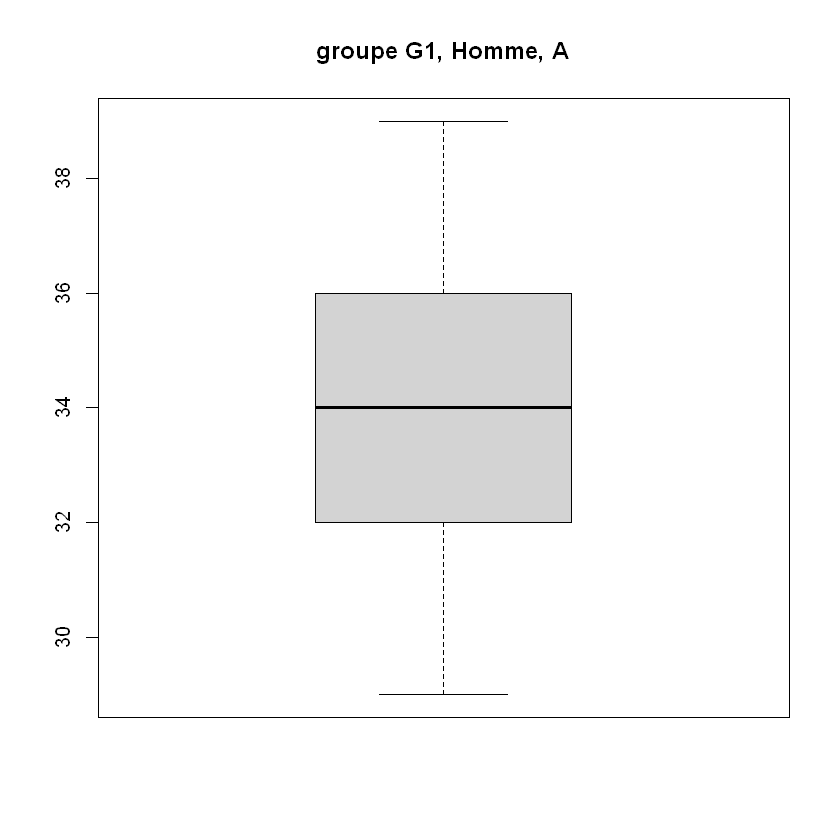

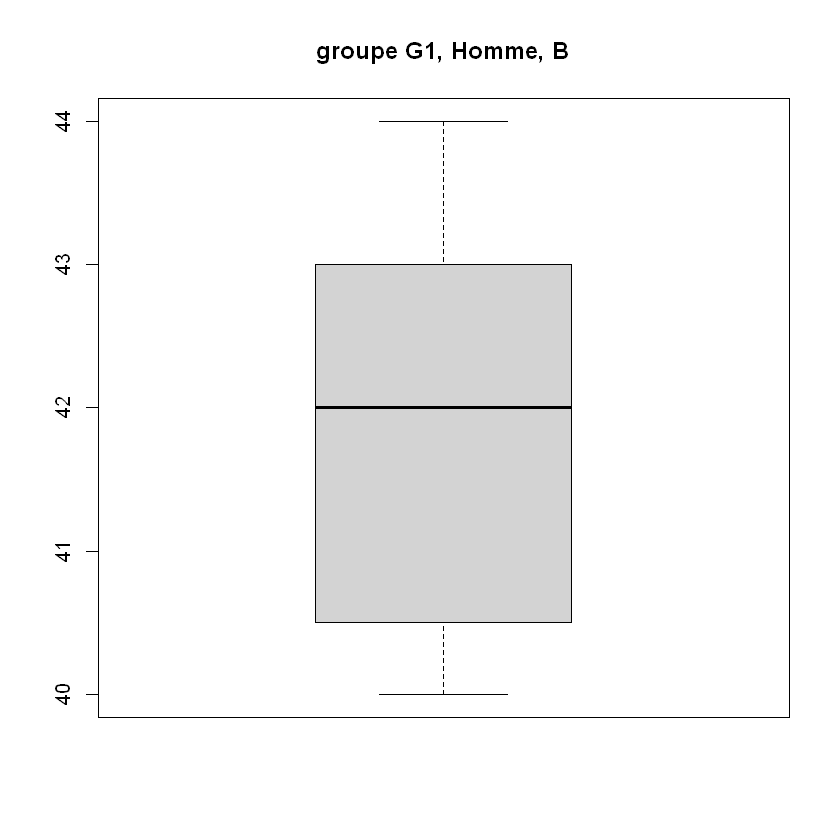

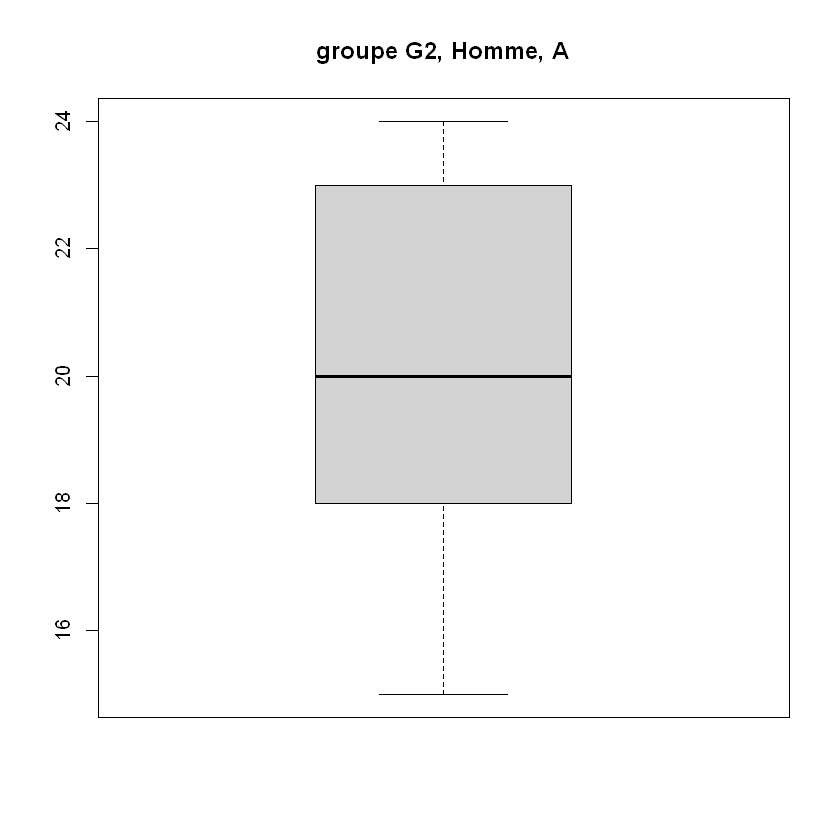

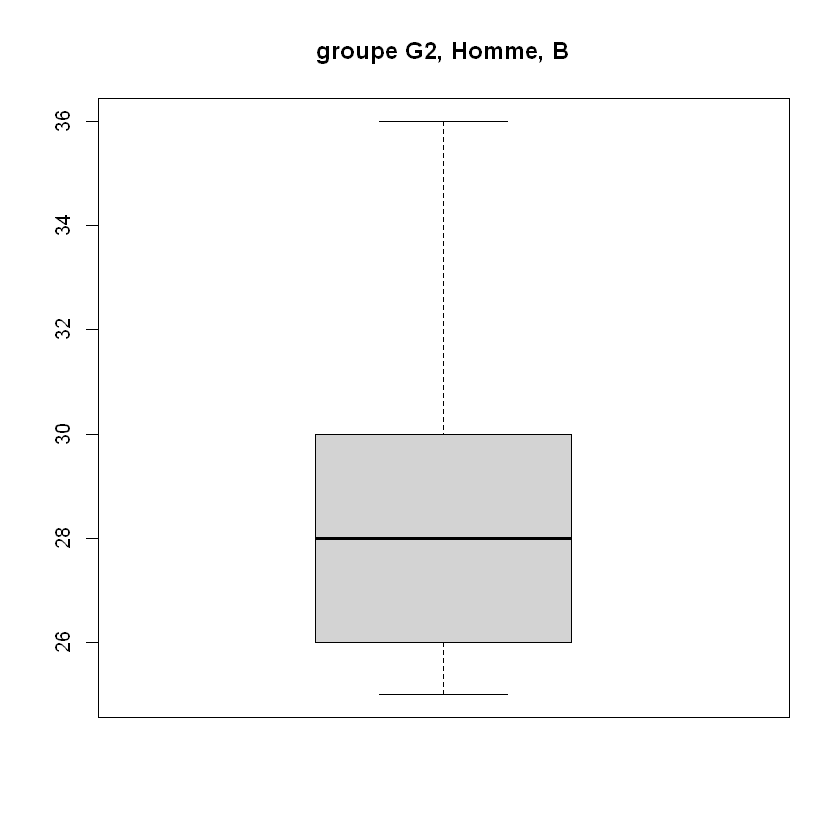

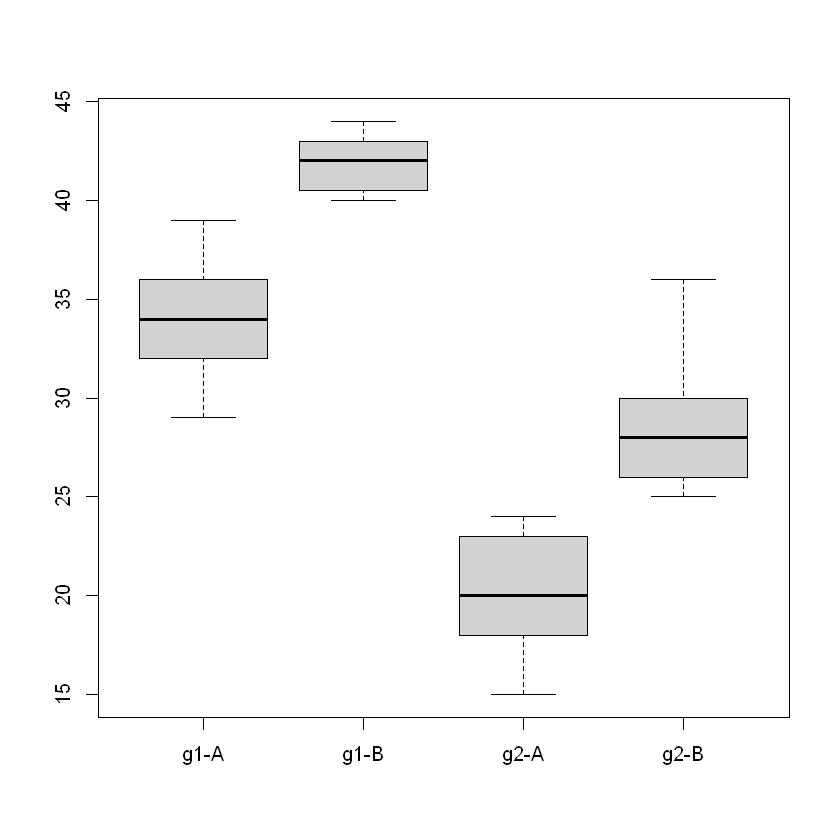

In [27]:
# Question 1 
boxplot(data_g1_homme$hamilton_g1[data_g1_homme$urbanisation_g1=="A"], main="groupe G1, Homme, A")

# Question 2 
boxplot(data_g1_homme$hamilton_g1[data_g1_homme$urbanisation_g1=="B"],main="groupe G1, Homme, B")

# Question 3 
boxplot(data_g2_homme$hamilton_g2[data_g2_homme$urbanisation_g2=="A"],main="groupe G2, Homme, A")

# Question 4 
boxplot(data_g2_homme$hamilton_g2[data_g2_homme$urbanisation_g2=="B"],main="groupe G2, Homme, B")

# Tout en même temps
boxplot(
    data_g1_homme$hamilton_g1[data_g1_homme$urbanisation_g1=="A"],
    data_g1_homme$hamilton_g1[data_g1_homme$urbanisation_g1=="B"],
    data_g2_homme$hamilton_g2[data_g2_homme$urbanisation_g2=="A"],
    data_g2_homme$hamilton_g2[data_g2_homme$urbanisation_g2=="B"],
    names = c("g1-A", "g1-B", "g2-A", "g2-B")
)

# Hypothèses : il semble qu'en plus d'un effet de l'acupuncture il semble y avoir un effet de l'urbanisation sur la dépression
# L'environnement le plus urbain semble augmenter la dépression.

### 6.3 Comparaison d'acceptation de crédit

On va reprendre le jeu de données `credit_approval.txt` utilisé dans les exercices du TD précédent

Le fichier `credit_approval.txt` dans le dossier `data/` décrit 50 ménages, formés de couples mariés hétérosexuels, tous deux actifs, qui ont déposé une demande de crédit auprès d’un établissement bancaire. Les variables disponibles sont les suivantes :

- `sal.homme` : logarithme du salaire annuel de l’homme,
- `sal.femme` : logarithme du salaire annuel de la femme,
- `rev.tete` : logarithme du revenu par tête c'est‐à‐dire total des revenus divisé par le nombre de personnes,
- `age` : logarithme de l’âge de l’homme,
- `acceptation` : accord du crédit par l’organisme prêteur (valeurs : "oui" ou "non"),
- `garantie.supp` : garantie supplémentaire demandée par l’organisme prêteur (valeurs : "caution", "hypotheque" ou "non"),
- `emploi` : type d’emploi occupé par la personne de référence lors de la demande de crédit (valeurs : "cdd" ou "cdi").

1. Combien de couples ont vu leur crédit acceptés sans avoir de garantie supplémentaire

In [28]:
credit = read.table("data/credit_approval.txt", header = TRUE)

# Première syntaxe
credit[credit$acceptation == "oui" & credit$garantie.supp == "non",]

# Deuxième syntaxe
subset(credit, acceptation == "oui" & garantie.supp == "non")

# => 11 couples

,sal.homme,sal.femme,rev.tete,age,acceptation,garantie.supp,emploi
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
9,7.48,7.25,6.46,3.47,oui,non,cdi
11,7.28,7.47,6.97,3.56,oui,non,cdi
14,8.42,8.01,7.83,3.47,oui,non,cdi
16,7.47,7.59,7.53,3.78,oui,non,cdi
28,7.63,7.77,6.79,3.66,oui,non,cdi
29,6.18,6.40,6.30,4.08,oui,non,cdi
30,7.57,7.53,6.63,3.43,oui,non,cdi
32,8.03,7.94,7.29,3.78,oui,non,cdi
35,7.92,7.92,6.82,3.66,oui,non,cdi


,sal.homme,sal.femme,rev.tete,age,acceptation,garantie.supp,emploi
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
9,7.48,7.25,6.46,3.47,oui,non,cdi
11,7.28,7.47,6.97,3.56,oui,non,cdi
14,8.42,8.01,7.83,3.47,oui,non,cdi
16,7.47,7.59,7.53,3.78,oui,non,cdi
28,7.63,7.77,6.79,3.66,oui,non,cdi
29,6.18,6.40,6.30,4.08,oui,non,cdi
30,7.57,7.53,6.63,3.43,oui,non,cdi
32,8.03,7.94,7.29,3.78,oui,non,cdi
35,7.92,7.92,6.82,3.66,oui,non,cdi


2. Combien de couples ont vu leur prêts refusés malgré un emploi en CDI ?

In [29]:
subset(credit, emploi == "cdi" & acceptation == "non")

,sal.homme,sal.femme,rev.tete,age,acceptation,garantie.supp,emploi
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
43,7.48,6.96,6.85,3.37,non,hypotheque,cdi
44,7.69,7.11,7.44,4.16,non,hypotheque,cdi
45,7.44,7.16,6.91,3.78,non,non,cdi
48,7.40,7.29,7.35,3.09,non,hypotheque,cdi
49,7.26,6.81,7.06,4.16,non,non,cdi
50,7.50,7.16,7.35,4.08,non,hypotheque,cdi


3. Représentez graphiquement les salaire des hommes du couples qui sont en CDD par rapport à ceux qui sont en CDI. Qu'en déduisez-vous ?

[1] 694.1725

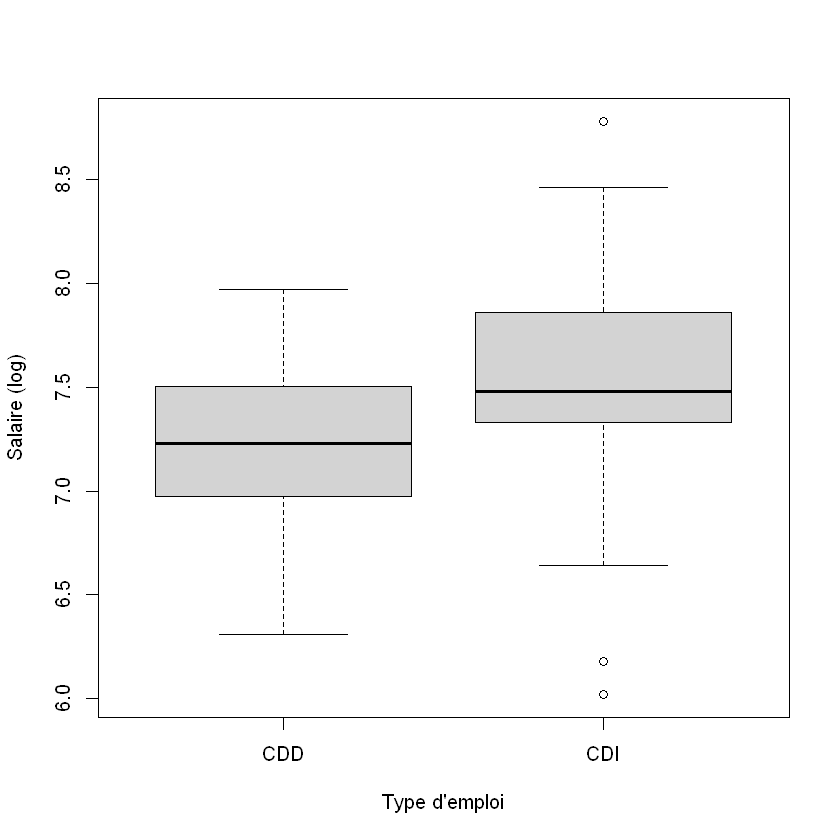

In [30]:
hommes_cdd = subset(credit, emploi == "cdd")$sal.homme
hommes_cdi = subset(credit, emploi == "cdi")$sal.homme

boxplot(hommes_cdd, hommes_cdi, xlab = "Type d'emploi", ylab = "Salaire (log)", names = c("CDD", "CDI"))

mean(exp(hommes_cdi)) - mean(exp(hommes_cdd))


# => les hommes en CDI gagnent davantage, en moyenne presque 700€ de plus que les hommes en CDD

4. Représentez graphiquement les salaire des femmes du couple dont le prêt a été accepté par rapport à ceux dont le prêt a été refusé. Qu'en déduisez-vous ?

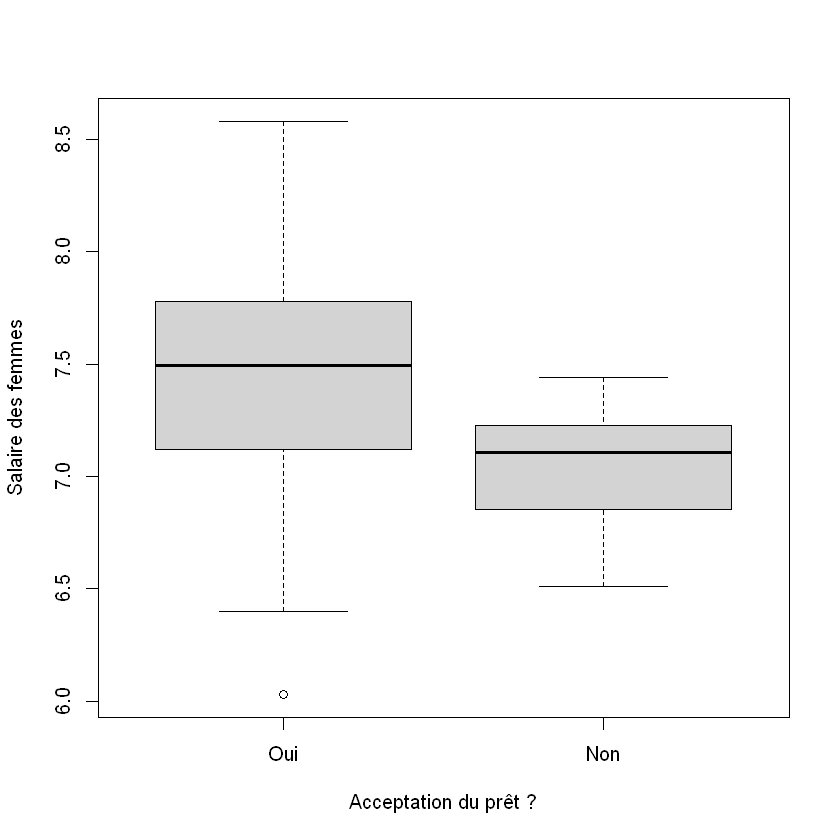

In [31]:
femmes_oui = subset(credit, acceptation == "oui")$sal.femme
femmes_non = subset(credit, acceptation == "non")$sal.femme

boxplot(femmes_oui, femmes_non, xlab = "Acceptation du prêt ?", ylab = "Salaire des femmes", names = c("Oui", "Non"))

# => Les femmes dont le couple a vu son prêt accepté gagnaient en moyenne mieux leur vie que celles dont le prêt a été refusé